In [1]:
%matplotlib inline
from qiskit.visualization.state_visualization import plot_state_city
from qiskit.quantum_info import random_clifford, Statevector, DensityMatrix
from circs import GHZ
import logging
logging.disable(level="CRITICAL")
logging.disable(level="INFO")

import matplotlib.pyplot as plt
import numpy as np

In [2]:
def XYZ(qc, g, idx):
    if g=="X":
        qc.h(idx)
    elif g=="Y":
        qc.sdg(idx)
        qc.h(idx)
    elif g=="Z" or g=="I":
        pass

### Inversion
As given we know the inversion for our case for a channel $\mathcal{M}$ is superficially
$$
 \mathcal{M_n}^{-1}(X) = (2^n+1)X-\mathbb{I}
$$
or therefore, generally
$$
 \hat{\rho} = \mathcal{M}^{-1}\left(U^\dagger|b\rangle\langle b|U \right) = (2^N+1)U^\dagger|b\rangle\langle b|U-\mathbb{I}
$$

In [3]:
def invert(N, X):
    d = 2**N
    UUd = np.outer(X, X.conj())
    # (2^N+1) UU+ - I
    return (d + 1)*UUd - np.eye(d)

In [35]:
N = 3
num_shadows = 10
shots = 8
cliffords = [random_clifford(N) for _ in range(num_shadows)]

qc = GHZ(N)

results = []
for clifford in cliffords:
    qc_c  = qc.compose(clifford.to_circuit())
    counts = Statevector(qc_c).sample_counts(shots)
    results.append(counts)

qc.draw()

┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐     
q_1: ─────┤ X ├──■──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘
c: 3/═══════════════

In [36]:
print(f"\n\n{N}-GHZ with Cliffords")
qc_c.draw()



3-GHZ with Cliffords


┌───┐     ┌───┐┌─────┐┌───┐                     ┌───┐ ┌───┐     
q_0: ┤ H ├──■──┤ Y ├┤ Sdg ├┤ H ├─────────────────■───┤ H ├─┤ S ├──■──
     └───┘┌─┴─┐└───┘└┬───┬┘├───┤┌───┐┌───┐       │  ┌┴───┴┐├───┤  │  
q_1: ─────┤ X ├──■───┤ Y ├─┤ S ├┤ H ├┤ S ├──■────┼──┤ Sdg ├┤ H ├──┼──
          └───┘┌─┴─┐ ├───┤ └───┘└───┘└───┘┌─┴─┐┌─┴─┐└┬───┬┘├───┤┌─┴─┐
q_2: ──────────┤ X ├─┤ Z ├────────────────┤ X ├┤ X ├─┤ H ├─┤ S ├┤ X ├
               └───┘ └───┘                └───┘└───┘ └───┘ └───┘└───┘
c: 3/════════════════════════════════════════════════════════════════

In [37]:
shadows = []
for clifford, result in zip(cliffords, results):
  mat = clifford.adjoint().to_matrix().T  # Transpose the matrix
  for bit, count in result.items():
    Ub = mat[int(bit, 2), :]
    shadows.append(invert(N, Ub) * count)

rho_shadow = np.sum(shadows, axis=0) / (num_shadows * shots)

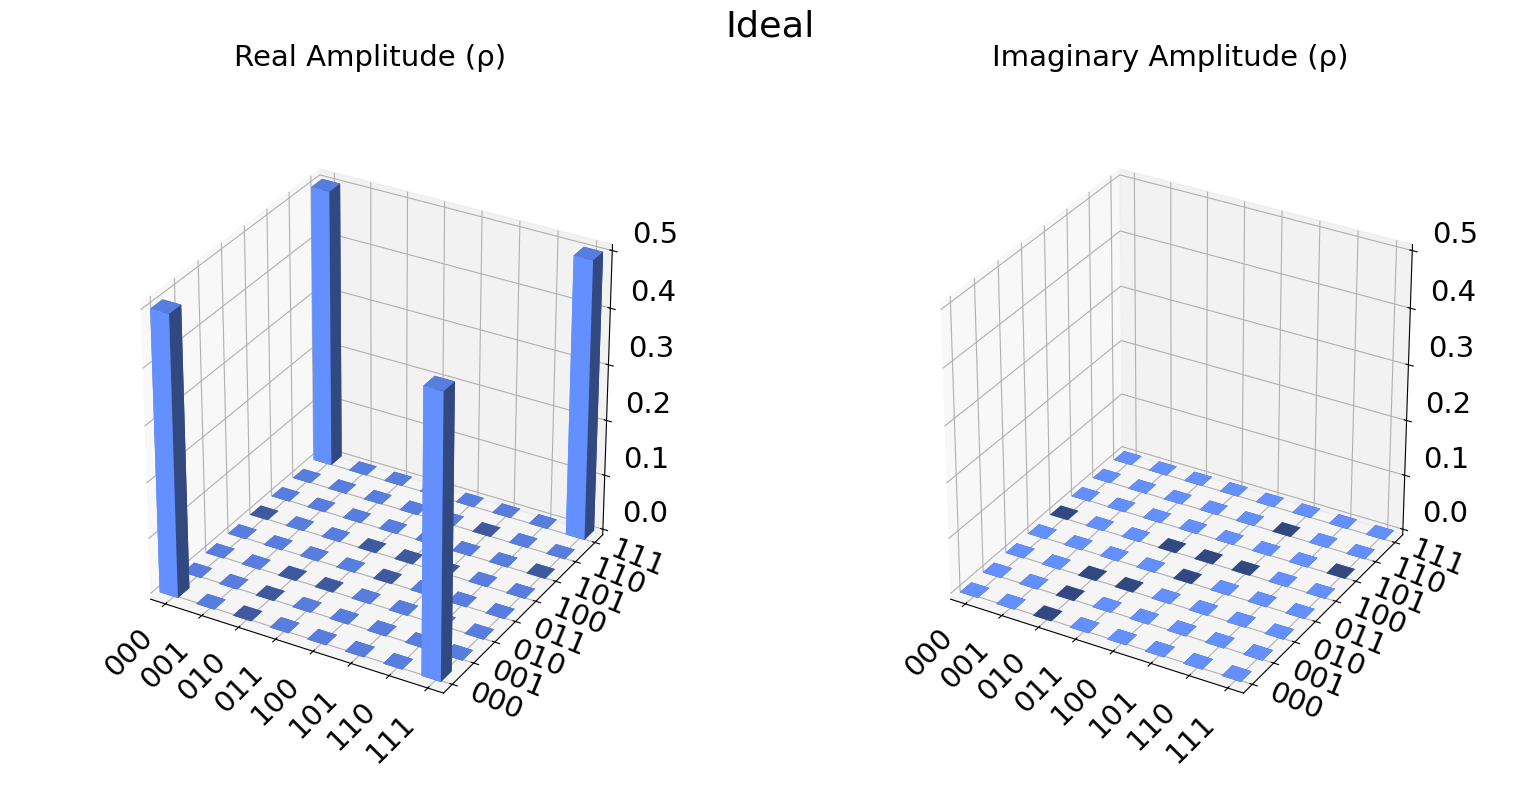

In [38]:
plot_state_city(DensityMatrix(qc).data, title="Ideal")

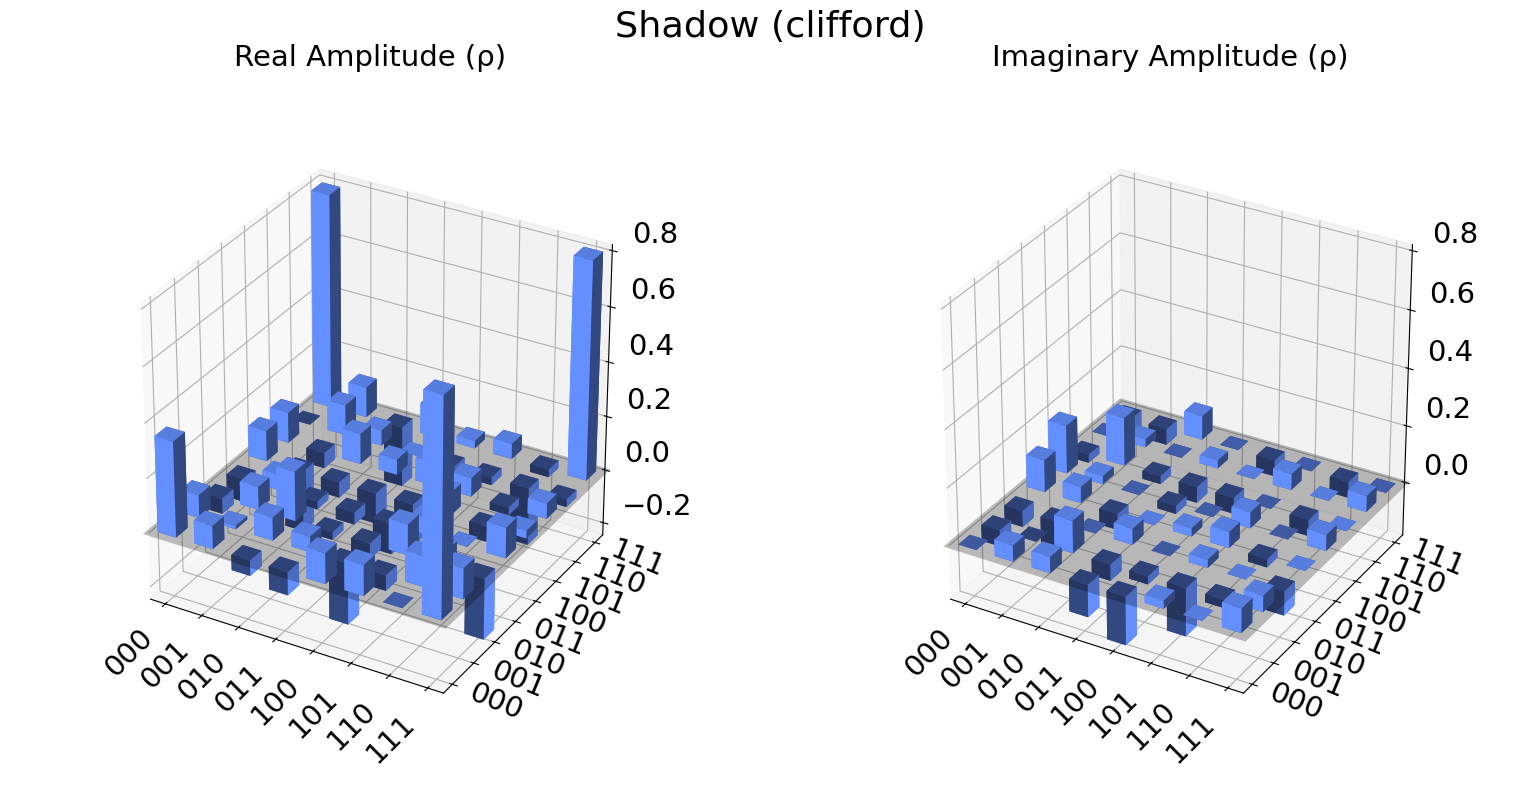

In [39]:
plot_state_city(rho_shadow,title="Shadow (clifford)")